# Proyecto: Clasificación de Subgéneros de Jazz (FMA)

## 1. Configuración del Entorno y Almacenamiento

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from collections import Counter
from imblearn.over_sampling import SMOTE, RandomOverSampler

import librosa
import sys
from src.extract_features import extraer_nombre_subgenero

import matplotlib.pyplot as plt

# Asegura que el directorio raíz del proyecto esté en el path (notebook en /notebooks)


print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Carga y Configuración de Rutas


In [28]:
# Rutas relativas (asumiendo que el notebook está en /notebooks y los datos en /data)
DATA_DIR = "../data/"
AUDIO_DIR = os.path.join(DATA_DIR, "audio_jazz/")

print("Cargando matrices preprocesadas...")
X_tabular = np.load(f"{DATA_DIR}X_tabular.npy")
X_cnn = np.load(f"{DATA_DIR}X_cnn.npy")
y_encoded = np.load(f"{DATA_DIR}y_encoded.npy")
classes = np.load(f"{DATA_DIR}classes.npy")

print(f"Forma de X_tabular (Random Forest): {X_tabular.shape}")
print(f"Forma de X_cnn (Red Neuronal): {X_cnn.shape}")
print(f"Clases detectadas: {classes}")

# Train/Test Split común para ambos
X_train_t, X_test_t, y_train, y_test = train_test_split(X_tabular, y_encoded, test_size=0.2, random_state=42)
X_train_m, X_test_m, _, _ = train_test_split(X_cnn, y_encoded, test_size=0.2, random_state=42)
todas_las_clases = np.arange(len(classes))

Cargando matrices preprocesadas...
Forma de X_tabular (Random Forest): (613, 74)
Forma de X_cnn (Red Neuronal): (613, 128, 128, 1)
Clases detectadas: ['Big Band/Swing' 'Free-Jazz' 'Jazz Generico' 'Jazz: Out' 'Jazz: Vocal'
 'Modern Jazz']


c:\Users\benja\Documents\Introducción al Aprendizaje Automático\proy\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


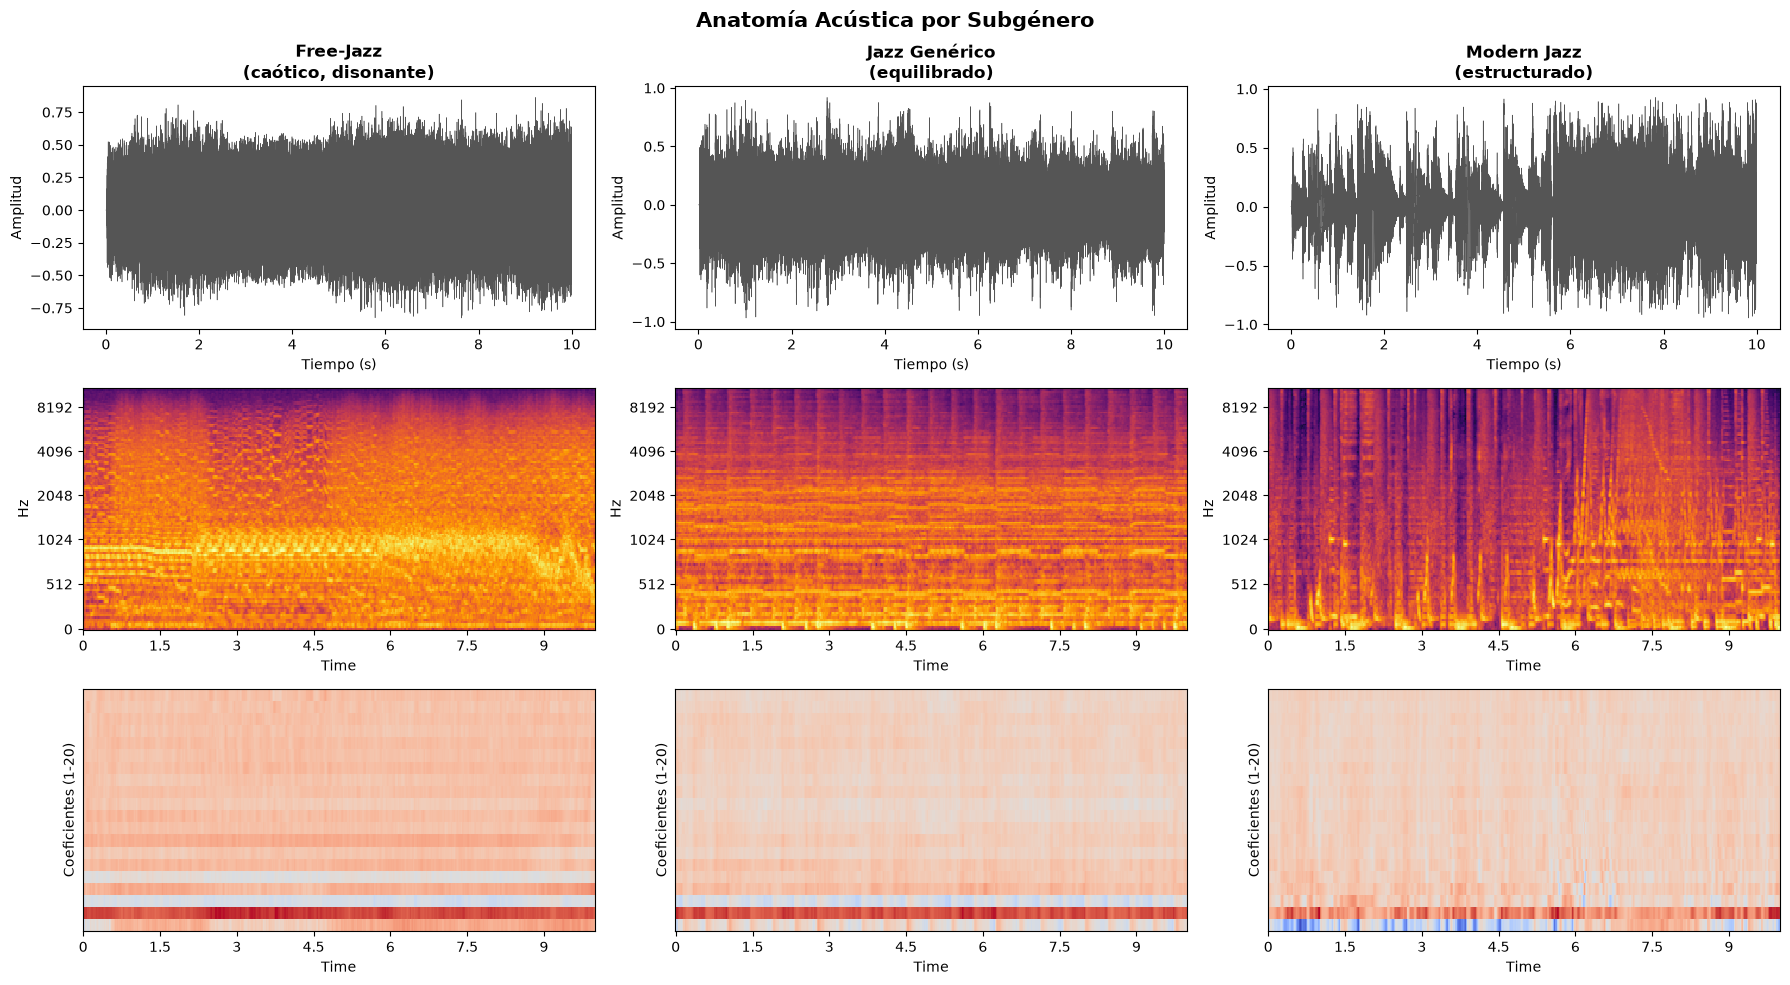

In [16]:
genres = pd.read_csv(os.path.join(DATA_DIR, 'fma_metadata/genres.csv'))
genre_map = dict(zip(genres['genre_id'].astype(str), genres['title']))
tracks = pd.read_csv(os.path.join(DATA_DIR, 'fma_metadata/tracks.csv'), index_col=0, header=[0, 1])
jazz_tracks = tracks[tracks[('track', 'genre_top')] == 'Jazz'].copy()
jazz_tracks['etiqueta_limpia'] = jazz_tracks[('track', 'genres')].astype(str).apply(lambda x: extraer_nombre_subgenero(x, genre_map))


fig, axes = plt.subplots(3, 3, figsize=(18, 10))
subgeneros = ["Free-Jazz", "Jazz Generico", "Modern Jazz"]

for col, subgenero in enumerate(subgeneros):
    # Busca un archivo del subgénero
    track_ids = jazz_tracks[jazz_tracks['etiqueta_limpia'] == subgenero].index.tolist()
    archivo = None
    for tid in track_ids[:10]:
        ruta = os.path.join(AUDIO_DIR, f"{str(tid).zfill(6)}.mp3")
        if os.path.exists(ruta):
            archivo = ruta
            break
    if archivo is None:
        continue

    y, sr = librosa.load(archivo, duration=10)
    tiempos = np.linspace(0, 10, len(y))

    # Fila 1: Forma de onda
    axes[0, col].plot(tiempos, y, linewidth=0.4, color='#555555')
    axes[0, col].set_title(subgenero, fontsize=13, fontweight='bold')
    axes[0, col].set_ylabel("Amplitud")
    axes[0, col].set_xlabel("Tiempo (s)")

    # Fila 2: Espectrograma de Mel
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel',
                             ax=axes[1, col], cmap='inferno')
    axes[1, col].set_ylabel("Hz")
    axes[1, col].set_xlabel("Time")

    # Fila 3: MFCCs
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    librosa.display.specshow(mfccs, sr=sr, x_axis='time',
                             ax=axes[2, col], cmap='coolwarm')
    axes[2, col].set_ylabel("Coeficientes (1-20)")
    axes[2, col].set_xlabel("Time")

axes[0, 0].set_title("Free-Jazz\n(caótico, disonante)", fontsize=12, fontweight='bold')
axes[0, 1].set_title("Jazz Genérico\n(equilibrado)", fontsize=12, fontweight='bold')
axes[0, 2].set_title("Modern Jazz\n(estructurado)", fontsize=12, fontweight='bold')

fig.suptitle("Anatomía Acústica por Subgénero", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/figures/anatomia_subgeneros.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Entrenamiento del Modelo RF con SMOTE y Optimización de Hiperparámetros 

In [17]:
print("--- Balanceando datos con SMOTE ---")

# 1. Averiguar el tamaño de la clase más pequeña en nuestro set de entrenamiento
conteo_clases = Counter(y_train)
min_muestras = min(conteo_clases.values())

# 2. Configurar los vecinos: SMOTE necesita que k_neighbors sea estrictamente 
# menor que la cantidad de muestras de la clase más pequeña.
k_vecinos = min(5, min_muestras - 1)

# 3. Lógica de seguridad (Fallback)
if k_vecinos < 1:
    print(f"¡Advertencia! La clase más pequeña tiene solo {min_muestras} muestra(s).")
    print("SMOTE requiere al menos 2. Usando RandomOverSampler (Clonación directa) como respaldo.")
    sampler = RandomOverSampler(random_state=42)
else:
    print(f"La clase más pequeña tiene {min_muestras} muestras.")
    print(f"Configurando SMOTE dinámico con k_neighbors={k_vecinos}")
    sampler = SMOTE(k_neighbors=k_vecinos, random_state=42)

# 4. Aplicar el balanceo seguro
X_train_t_smote, y_train_smote = sampler.fit_resample(X_train_t, y_train)

print(f"Distribución antes: {dict(conteo_clases)}")
print(f"Distribución después: {dict(Counter(y_train_smote))}")

print("--- Optimizando Random Forest con Búsqueda Aleatoria ---")
# Definimos una "cuadrícula" de posibles configuraciones para el bosque
param_grid = {
    'n_estimators': [100, 200, 400, 600],
    'max_depth': [None, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

rf_base = RandomForestClassifier(random_state=42, class_weight='balanced_subsample')

# Prueba 200 combinaciones distintas al azar buscando la mejor (n_iter=200)
rf_random = RandomizedSearchCV(estimator=rf_base, param_distributions=param_grid, 
                               n_iter=200, cv=3, verbose=2, random_state=42, n_jobs=-1)

# Entrenamos usando los datos que ya balanceamos con SMOTE previamente
rf_random.fit(X_train_t_smote, y_train_smote)

print("\n[!] ¡Búsqueda terminada!")
print(f"Mejores parámetros encontrados: {rf_random.best_params_}")

# Predecimos con el mejor modelo encontrado
mejor_rf = rf_random.best_estimator_
y_pred_rf_opt = mejor_rf.predict(X_test_t)

print("\n=== REPORTE RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf_opt, labels=todas_las_clases, target_names=classes, zero_division=0))

--- Balanceando datos con SMOTE ---
La clase más pequeña tiene 15 muestras.
Configurando SMOTE dinámico con k_neighbors=5


c:\Users\benja\Documents\Introducción al Aprendizaje Automático\proy\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\benja\Documents\Introducción al Aprendizaje Automático\proy\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\benja\Documents\Introducción al Aprendizaje Automático\proy\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\U

Distribución antes: {5: 51, 2: 204, 0: 15, 3: 44, 4: 43, 1: 133}
Distribución después: {5: 204, 2: 204, 0: 204, 3: 204, 4: 204, 1: 204}
--- Optimizando Random Forest con Búsqueda Aleatoria ---
Fitting 3 folds for each of 200 candidates, totalling 600 fits

[!] ¡Búsqueda terminada!
Mejores parámetros encontrados: {'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20, 'bootstrap': False}

=== REPORTE RANDOM FOREST ===
                precision    recall  f1-score   support

Big Band/Swing       1.00      0.67      0.80         3
     Free-Jazz       0.88      0.66      0.75        35
 Jazz Generico       0.62      0.89      0.73        46
     Jazz: Out       0.86      0.46      0.60        13
   Jazz: Vocal       0.62      0.62      0.62         8
   Modern Jazz       0.86      0.67      0.75        18

      accuracy                           0.72       123
     macro avg       0.81      0.66      0.71       123
  weighted avg       0.77      0.72      0.

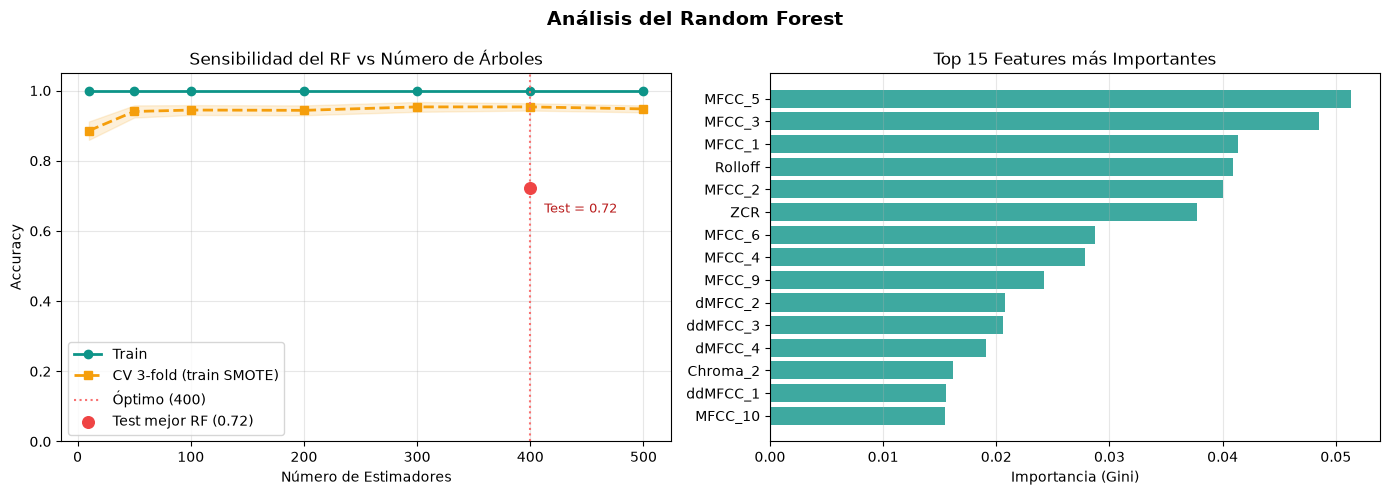

In [22]:
# Curva: accuracy vs número de árboles
n_estimators_range = [10, 50, 100, 200, 300, 400, 500]
train_scores, cv_scores, cv_stds = [], [], []

for n in n_estimators_range:
    rf_temp = RandomForestClassifier(
        n_estimators=n,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=1,
        bootstrap=False,
        random_state=42,
        n_jobs=-1
    )
    rf_temp.fit(X_train_t_smote, y_train_smote)
    train_scores.append(rf_temp.score(X_train_t_smote, y_train_smote))
    cv_result = cross_val_score(rf_temp, X_train_t_smote, y_train_smote, cv=3, n_jobs=-1)
    cv_scores.append(cv_result.mean())
    cv_stds.append(cv_result.std())

rf_test_accuracy = mejor_rf.score(X_test_t, y_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Izquierda: accuracy vs n_estimators
ax1.plot(n_estimators_range, train_scores, 'o-', color='#0D9488', 
         label='Train', linewidth=2)
ax1.plot(n_estimators_range, cv_scores, 's--', color='#F59E0B', 
         label='CV 3-fold (train SMOTE)', linewidth=2)
ax1.fill_between(n_estimators_range, 
                 np.array(cv_scores) - np.array(cv_stds), 
                 np.array(cv_scores) + np.array(cv_stds), 
                 color='#F59E0B', alpha=0.15)
ax1.axvline(x=mejor_rf.n_estimators, color='#F87171', linestyle=':', linewidth=1.5, 
            label=f'Óptimo ({mejor_rf.n_estimators})')
ax1.scatter([mejor_rf.n_estimators], [rf_test_accuracy], color='#EF4444', s=70, 
            zorder=5, label=f'Test mejor RF ({rf_test_accuracy:.2f})')
ax1.annotate(f'Test = {rf_test_accuracy:.2f}', 
             (mejor_rf.n_estimators, rf_test_accuracy), 
             textcoords='offset points', xytext=(10, -18), 
             color='#B91C1C', fontsize=9)
ax1.set_xlabel('Número de Estimadores')
ax1.set_ylabel('Accuracy')
ax1.set_title('Sensibilidad del RF vs Número de Árboles')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1.05)

# Derecha: importancia de features (top 15)
importancias = mejor_rf.feature_importances_
nombres = (
    [f'MFCC_{i+1}' for i in range(20)] +
    [f'dMFCC_{i+1}' for i in range(20)] +
    [f'ddMFCC_{i+1}' for i in range(20)] +
    [f'Chroma_{i+1}' for i in range(12)] +
    ['Rolloff', 'ZCR']
)
indices = np.argsort(importancias)[-15:]

ax2.barh(range(15), importancias[indices], color='#0D9488', alpha=0.8)
ax2.set_yticks(range(15))
ax2.set_yticklabels([nombres[i] for i in indices])
ax2.set_xlabel('Importancia (Gini)')
ax2.set_title('Top 15 Features más Importantes')
ax2.grid(True, alpha=0.3, axis='x')

plt.suptitle('Análisis del Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/figures/rf_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Entrenamiento del Modelo CNN con Regularización L2 y Normalización por Lotes (Batch Normalization)

In [29]:
print("--- Configurando CNN con Data Augmentation ---")
# Pesos suavizados (Clipping)
pesos_crudos = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
pesos_suavizados = np.clip(pesos_crudos, a_min=1.0, a_max=4.0)
pesos_dict = dict(enumerate(pesos_suavizados))

# Generador de imágenes alteradas
datagen = ImageDataGenerator(width_shift_range=0.1, height_shift_range=0.1, fill_mode='nearest')

print("\n--- Entrenando CNN  ---")

cnn_model_opt = models.Sequential([
    layers.Input(shape=(128, 128, 1)),
    
    layers.Conv2D(16, (3, 3), padding='same', activation='relu',
                  kernel_regularizer=regularizers.l2(1e-3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                  kernel_regularizer=regularizers.l2(1e-3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), padding='same', activation='relu',
                  kernel_regularizer=regularizers.l2(1e-3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    layers.GlobalAveragePooling2D(),  # En vez de Flatten
    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(1e-3)),
    layers.Dropout(0.4),
    layers.Dense(len(classes), activation='softmax')
])

cnn_model_opt.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Callbacks: Si la red deja de mejorar por 10 épocas, se detiene sola. 
# Si se estanca, reduce la velocidad de aprendizaje.
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10)

# Entrenamos DIRECTAMENTE sobre X_train_m (sin el datagen que rompía la imagen)
history = cnn_model_opt.fit(
    X_train_m, y_train,
    epochs=200,
    batch_size=32,
    validation_data=(X_test_m, y_test),
    #class_weight=pesos_dict, # Seguimos usando los pesos suavizados
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

y_pred_cnn_opt = np.argmax(cnn_model_opt.predict(X_test_m), axis=1)

print("\n=== REPORTE CNN ===")
print(classification_report(y_test, y_pred_cnn_opt, labels=todas_las_clases, target_names=classes, zero_division=0))

--- Configurando CNN con Data Augmentation ---

--- Entrenando CNN  ---
Epoch 1/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.2694 - loss: 1.9237 - val_accuracy: 0.2846 - val_loss: 1.8926 - learning_rate: 3.0000e-04
Epoch 2/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.3918 - loss: 1.6905 - val_accuracy: 0.2846 - val_loss: 1.8765 - learning_rate: 3.0000e-04
Epoch 3/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.4061 - loss: 1.6191 - val_accuracy: 0.2846 - val_loss: 1.8825 - learning_rate: 3.0000e-04
Epoch 4/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.4306 - loss: 1.5848 - val_accuracy: 0.2846 - val_loss: 1.8866 - learning_rate: 3.0000e-04
Epoch 5/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.4592 - loss: 1.5078 - val_accuracy: 0.2846 - val_loss: 1.8970 - learning_rate: 3.0000e-04
Epoch 6/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.4735 - loss: 1.4900 - val_accuracy: 0.2846 - val_loss: 1.8967 - learning_rate: 3.0

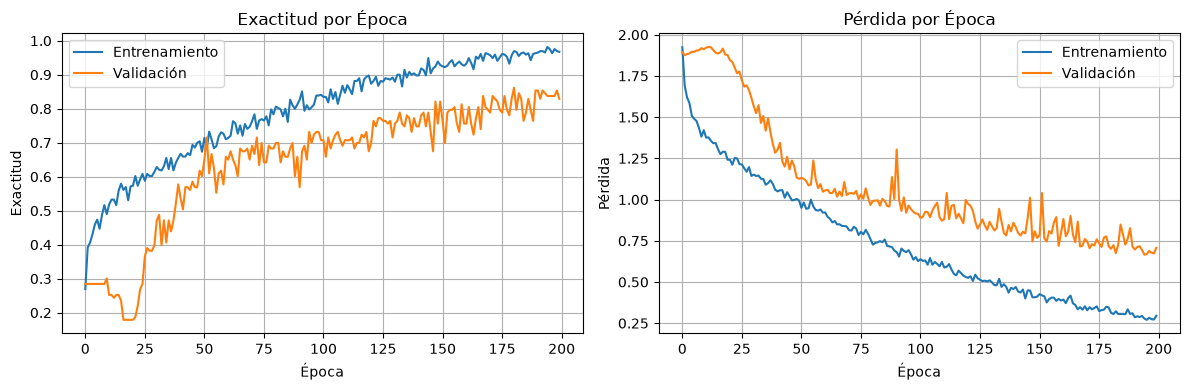

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
ax1.plot(history.history['accuracy'], label='Entrenamiento')
ax1.plot(history.history['val_accuracy'], label='Validación')
ax1.set_title('Exactitud por Época')
ax1.set_xlabel('Época')
ax1.set_ylabel('Exactitud')
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(history.history['loss'], label='Entrenamiento')
ax2.plot(history.history['val_loss'], label='Validación')
ax2.set_title('Pérdida por Época')
ax2.set_xlabel('Época')
ax2.set_ylabel('Pérdida')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('../report/figures/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Evaluación de Modelos y Comparación de Resultados

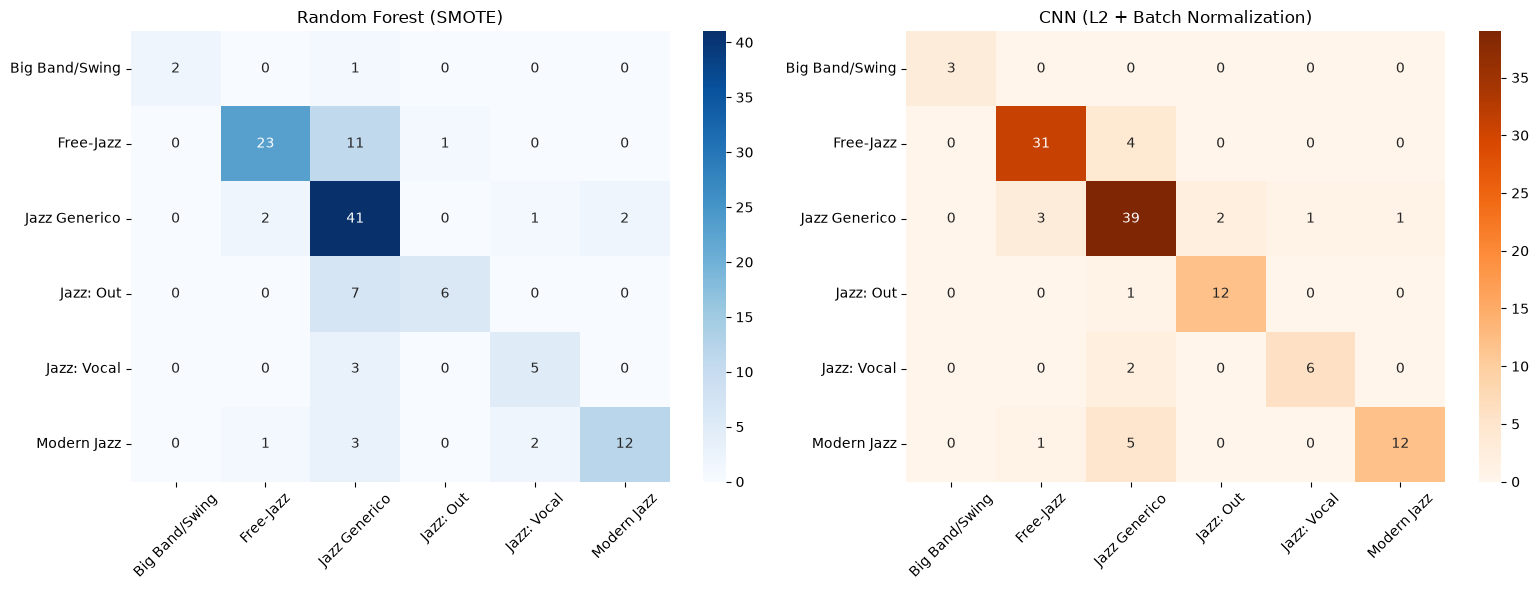

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(confusion_matrix(y_test, y_pred_rf_opt, labels=todas_las_clases), 
            annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=ax[0])
ax[0].set_title('Random Forest (SMOTE)')
ax[0].tick_params(axis='x', rotation=45)

sns.heatmap(confusion_matrix(y_test, y_pred_cnn_opt, labels=todas_las_clases), 
            annot=True, fmt='d', cmap='Oranges',
            xticklabels=classes, yticklabels=classes, ax=ax[1])
ax[1].set_title('CNN (L2 + Batch Normalization)')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../report/figures/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Ensamble de Modelos y Predicciones Finales

In [43]:
print("--- CREANDO EL ENSAMBLE HÍBRIDO (WEIGHTED SOFT VOTING) ---")

# 1. Pedirle a los modelos su % de seguridad (probabilidades) con los datos de prueba
# (Asegúrate de usar los nombres de variables correctos que tienes en tu notebook)
probs_rf = mejor_rf.predict_proba(X_test_t) # El mejor Random Forest del GridSearch
probs_cnn = cnn_model_opt.predict(X_test_m) # La CNN optimizada

# 2. El Comité Vota: Le damos 75% de peso al RF y 25% a la CNN
probs_ensamble = (probs_rf * 0.75) + (probs_cnn * 0.25)

# 3. La decisión final es la clase con la probabilidad sumada más alta
y_pred_ensamble = np.argmax(probs_ensamble, axis=1)

print("\n=== REPORTE ENSAMBLE HÍBRIDO FINAL ===")
print(classification_report(y_test, y_pred_ensamble, labels=todas_las_clases, target_names=classes, zero_division=0))

--- CREANDO EL ENSAMBLE HÍBRIDO (WEIGHTED SOFT VOTING) ---
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

=== REPORTE ENSAMBLE HÍBRIDO FINAL ===
                precision    recall  f1-score   support

Big Band/Swing       1.00      0.67      0.80         3
     Free-Jazz       0.93      0.80      0.86        35
 Jazz Generico       0.76      0.96      0.85        46
     Jazz: Out       0.92      0.92      0.92        13
   Jazz: Vocal       0.83      0.62      0.71         8
   Modern Jazz       1.00      0.78      0.88        18

      accuracy                           0.85       123
     macro avg       0.91      0.79      0.84       123
  weighted avg       0.87      0.85      0.85       123



### Testing

In [36]:
def predecir_cancion_nueva(ruta_mp3, modelo_rf, modelo_cnn, clases_nombres):
    """
    Toma cualquier archivo MP3, extrae su cinemática y su espectrograma,
    y hace que el Ensamble Híbrido vote para predecir su subgénero de Jazz.
    """
    print(f"E scuchando e interpretando pista: {ruta_mp3}...")
    
    try:
        # 1. Cargar los primeros 30 segundos del audio
        y, sr = librosa.load(ruta_mp3, duration=30)
        
        # 2. Extraer Características Físicas (Matemáticas)
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
        delta_mfccs = librosa.feature.delta(mfccs)
        delta2_mfccs = librosa.feature.delta(mfccs, order=2)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        
        rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
        zcr = librosa.feature.zero_crossing_rate(y)
        
        feat_tabular = np.hstack([
            np.mean(mfccs.T, axis=0),
            np.mean(delta_mfccs.T, axis=0),
            np.mean(delta2_mfccs.T, axis=0),
            np.mean(chroma.T, axis=0),
            np.mean(rolloff),   
            np.mean(zcr)        
        ]).reshape(1, -1) # Reshape porque es 1 sola canción
        
        # 3. Extraer Características Visuales (Espectrograma para CNN)
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        # Normalizar:
        mel_db_norm = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
        mel_resized = tf.image.resize(mel_db_norm[..., np.newaxis], [128, 128]).numpy()
        feat_cnn = mel_resized.reshape(1, 128, 128, 1)

        # 4. El Comité Vota (Predicción)
        prob_rf = modelo_rf.predict_proba(feat_tabular)
        prob_cnn = modelo_cnn.predict(feat_cnn, verbose=0)
        
        # Pesos del ensamble (50% Random Forest, 50% CNN)
        prob_final = (prob_rf * 0.5) + (prob_cnn * 0.5)
        
        # 5. Obtener el ganador
        indice_ganador = np.argmax(prob_final, axis=1)[0]
        confianza = np.max(prob_final) * 100
        genero_predicho = clases_nombres[indice_ganador]
        
        print("\n" + "="*40)
        print(f"¡ANÁLISIS COMPLETADO!")
        print(f"Subgénero detectado: {genero_predicho.upper()}")
        print(f"Nivel de Confianza: {confianza:.2f}%")
        print("="*40 + "\n")
        
        return genero_predicho
        
    except Exception as e:
        print(f"Error al procesar el audio: {e}")

In [37]:
# Reemplaza 'mi_audio' con el nombre de la canción que descargues
TEST_AUDIO_DIR = "../data/test_audio/"
mi_audio = "test2.mp3" 
ruta_audio = TEST_AUDIO_DIR + mi_audio

# Asumiendo que tus modelos se llaman mejor_rf y cnn_model_opt
predecir_cancion_nueva(ruta_audio, mejor_rf, cnn_model_opt, classes)

E scuchando e interpretando pista: ../data/test_audio/test2.mp3...

¡ANÁLISIS COMPLETADO!
Subgénero detectado: JAZZ GENERICO
Nivel de Confianza: 57.61%



'Jazz Generico'